In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("dataset/wdbc.data", header=None)

print(df.head())

         0  1      2      3       4       5        6        7       8   \
0    842302  M  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.3001   
1    842517  M  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.0869   
2  84300903  M  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.1974   
3  84348301  M  11.42  20.38   77.58   386.1  0.14250  0.28390  0.2414   
4  84358402  M  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.1980   

        9   ...     22     23      24      25      26      27      28      29  \
0  0.14710  ...  25.38  17.33  184.60  2019.0  0.1622  0.6656  0.7119  0.2654   
1  0.07017  ...  24.99  23.41  158.80  1956.0  0.1238  0.1866  0.2416  0.1860   
2  0.12790  ...  23.57  25.53  152.50  1709.0  0.1444  0.4245  0.4504  0.2430   
3  0.10520  ...  14.91  26.50   98.87   567.7  0.2098  0.8663  0.6869  0.2575   
4  0.10430  ...  22.54  16.67  152.20  1575.0  0.1374  0.2050  0.4000  0.1625   

       30       31  
0  0.4601  0.11890  
1  0.2750  0.08902  
2  0.

In [9]:
columns = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
df.columns = columns

print(df.head())

         id diagnosis  feature_1  feature_2  feature_3  feature_4  feature_5  \
0    842302         M      17.99      10.38     122.80     1001.0    0.11840   
1    842517         M      20.57      17.77     132.90     1326.0    0.08474   
2  84300903         M      19.69      21.25     130.00     1203.0    0.10960   
3  84348301         M      11.42      20.38      77.58      386.1    0.14250   
4  84358402         M      20.29      14.34     135.10     1297.0    0.10030   

   feature_6  feature_7  feature_8  ...  feature_21  feature_22  feature_23  \
0    0.27760     0.3001    0.14710  ...       25.38       17.33      184.60   
1    0.07864     0.0869    0.07017  ...       24.99       23.41      158.80   
2    0.15990     0.1974    0.12790  ...       23.57       25.53      152.50   
3    0.28390     0.2414    0.10520  ...       14.91       26.50       98.87   
4    0.13280     0.1980    0.10430  ...       22.54       16.67      152.20   

   feature_24  feature_25  feature_26  featu

In [10]:
df['diagnosis'] = df['diagnosis'].map({'M': 0, 'B': 1})

In [11]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
print(df['diagnosis'].value_counts())

diagnosis
1    357
0    212
Name: count, dtype: int64


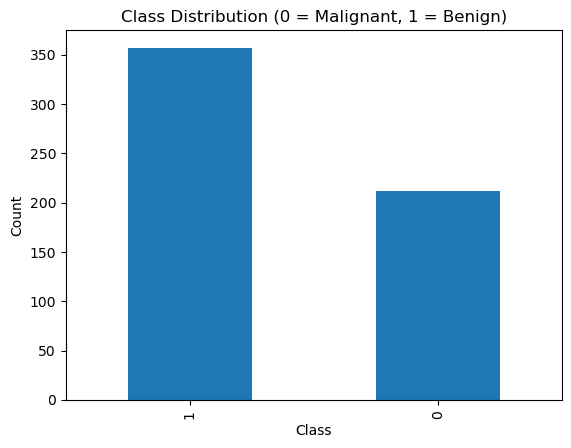

In [15]:
df['diagnosis'].value_counts().plot(kind='bar')
plt.title("Class Distribution (0 = Malignant, 1 = Benign)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.savefig("Class distribution")
plt.show()

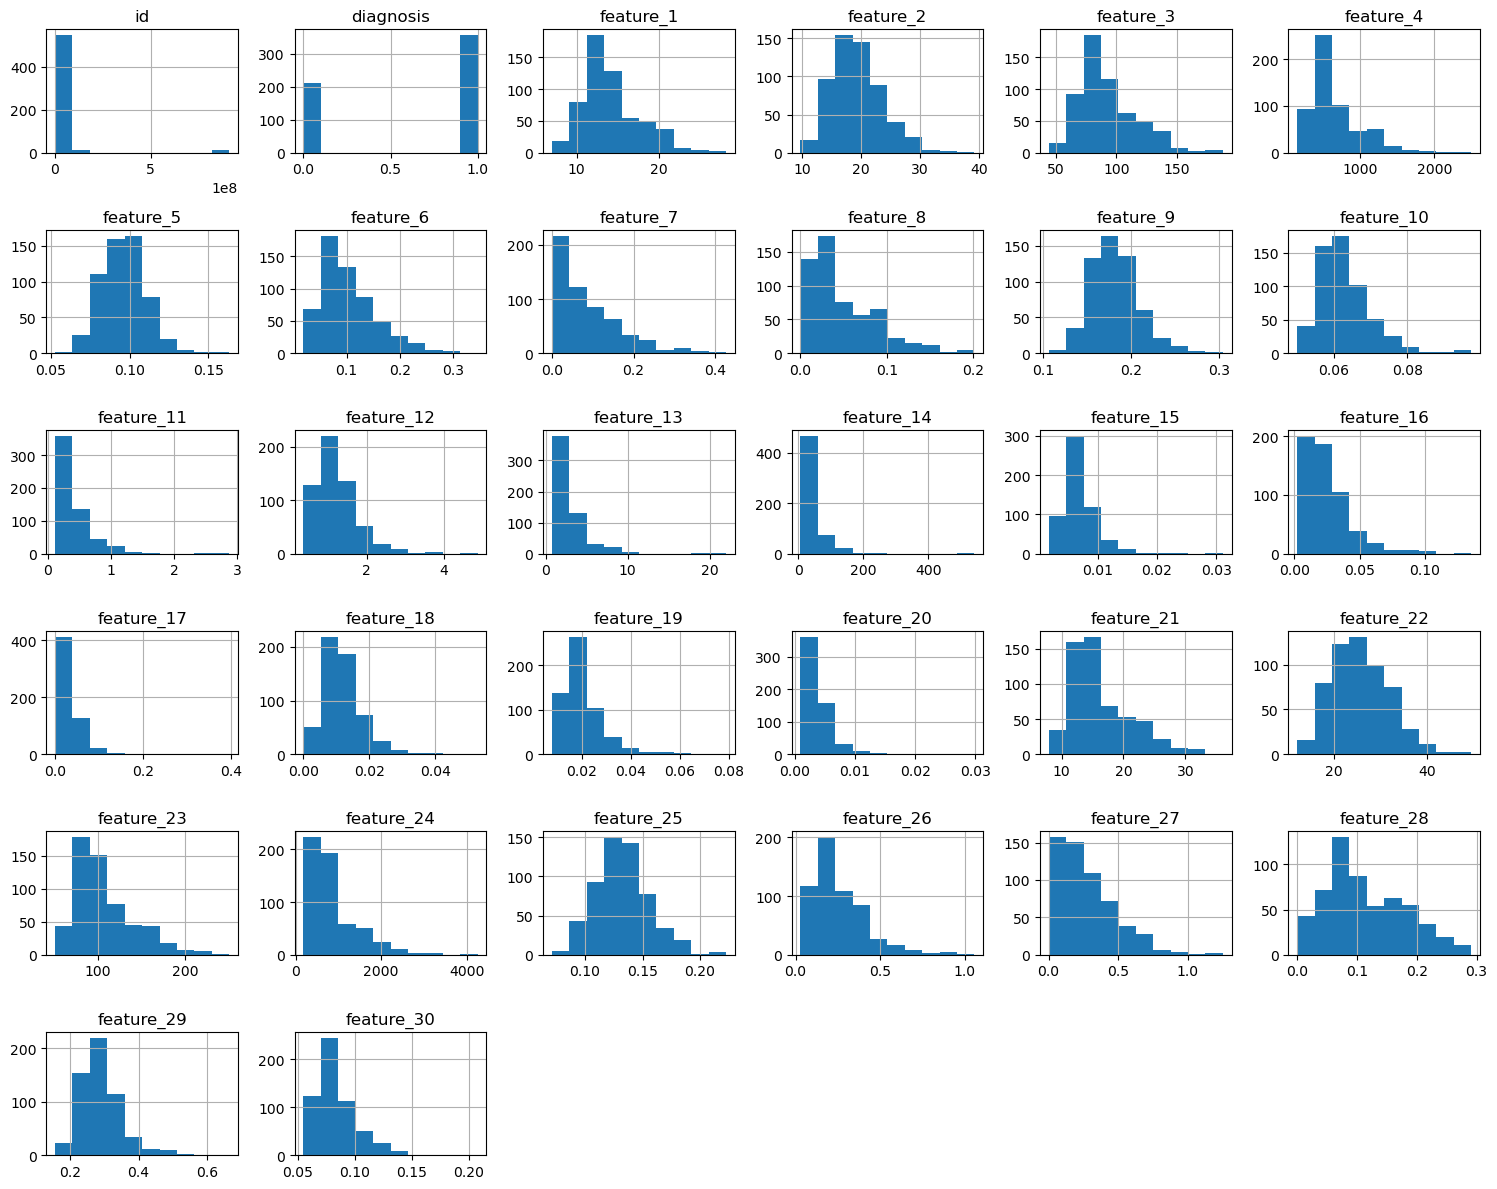

In [16]:
df.hist(figsize=(15, 12))
plt.tight_layout()
plt.savefig("histogram")
plt.show()

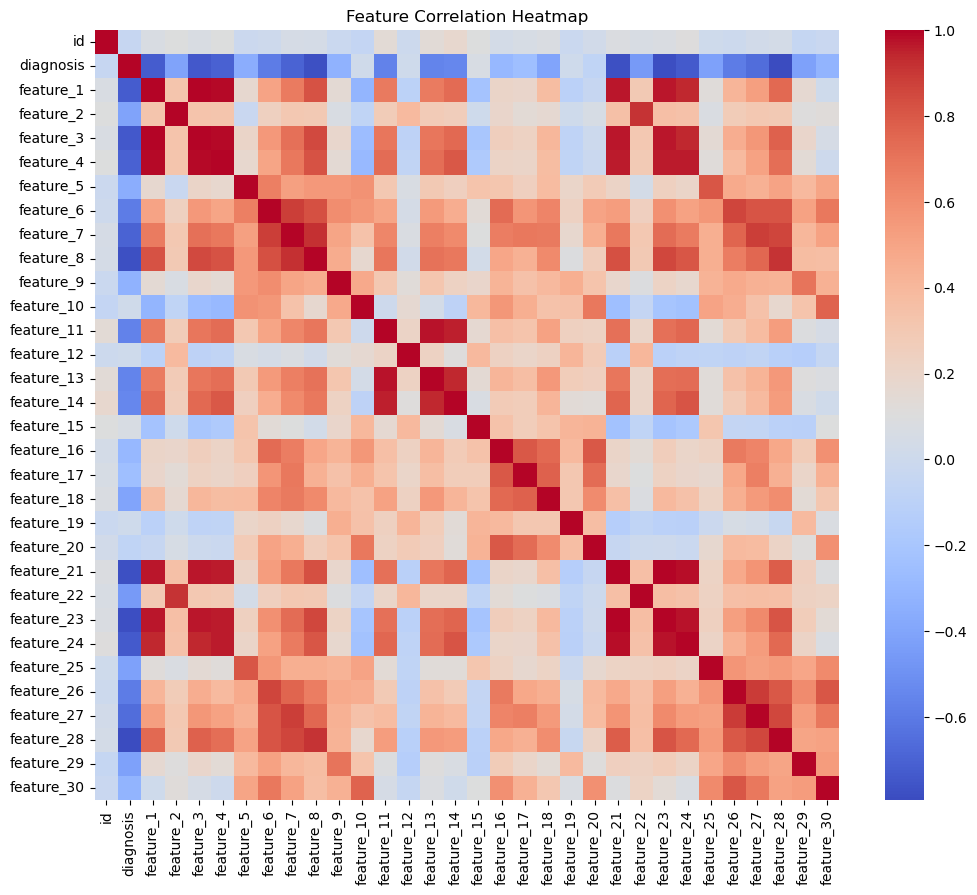

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.savefig("Correlation heatmap")
plt.show()

In [18]:
corr = df.corr()['diagnosis'].sort_values(ascending=False)
print(corr)

diagnosis     1.000000
feature_15    0.067016
feature_10    0.012838
feature_12    0.008303
feature_19    0.006522
id           -0.039769
feature_20   -0.077972
feature_17   -0.253730
feature_16   -0.292999
feature_30   -0.323872
feature_9    -0.330499
feature_5    -0.358560
feature_18   -0.408042
feature_2    -0.415185
feature_29   -0.416294
feature_25   -0.421465
feature_22   -0.456903
feature_14   -0.548236
feature_13   -0.556141
feature_11   -0.567134
feature_26   -0.590998
feature_6    -0.596534
feature_27   -0.659610
feature_7    -0.696360
feature_4    -0.708984
feature_1    -0.730029
feature_24   -0.733825
feature_3    -0.742636
feature_21   -0.776454
feature_8    -0.776614
feature_23   -0.782914
feature_28   -0.793566
Name: diagnosis, dtype: float64


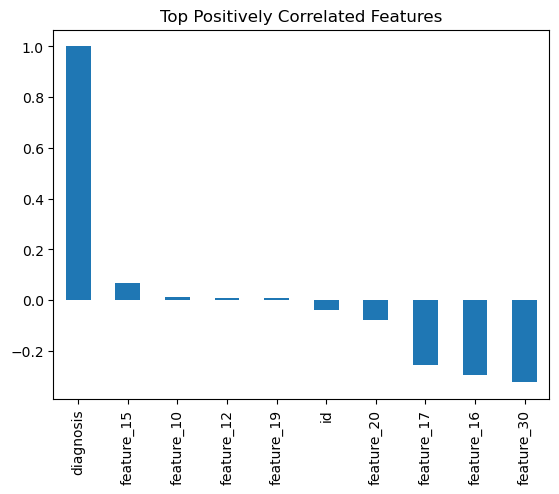

In [19]:
corr.head(10).plot(kind='bar')
plt.title("Top Positively Correlated Features")
plt.savefig("Top Positively Correlated Features")
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # VERY IMPORTANT (keeps class balance)
)

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

In [22]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=10,
    random_state=42
)

bagging_model.fit(X_train_scaled, y_train)

y_pred_bag = bagging_model.predict(X_test_scaled)

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_bag))
print("Precision:", precision_score(y_test, y_pred_bag))
print("Recall:", recall_score(y_test, y_pred_bag))
print("F1 Score:", f1_score(y_test, y_pred_bag))

Accuracy: 0.9385964912280702
Precision: 0.9577464788732394
Recall: 0.9444444444444444
F1 Score: 0.951048951048951


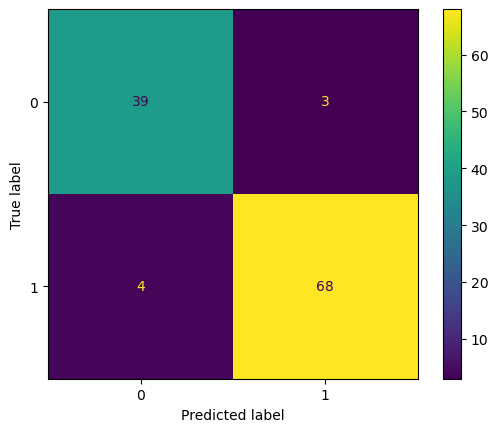

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(bagging_model, X_test_scaled, y_test)

In [25]:
from sklearn.model_selection import cross_val_score

n_estimators_list = [5, 10, 20, 50]
max_samples_list = [0.5, 0.7, 1.0]

results = []

for n in n_estimators_list:
    for m in max_samples_list:
        model = BaggingClassifier(
            estimator=DecisionTreeClassifier(),
            n_estimators=n,
            max_samples=m,
            random_state=42
        )
        
        # Accuracy
        acc_scores = cross_val_score(
            model, X_train_scaled, y_train,
            cv=5, scoring='accuracy'
        )
        
        # F1 Score
        f1_scores = cross_val_score(
            model, X_train_scaled, y_train,
            cv=5, scoring='f1'
        )
        
        results.append([
            n,
            m,
            acc_scores.mean(),
            f1_scores.mean()
        ])

In [26]:
bagging_results = pd.DataFrame(results, columns=[
    'n_estimators',
    'max_samples',
    'Avg_CV_Accuracy',
    'Avg_CV_F1_Score'
])

print(bagging_results)

    n_estimators  max_samples  Avg_CV_Accuracy  Avg_CV_F1_Score
0              5          0.5         0.923077         0.938762
1              5          0.7         0.942857         0.955192
2              5          1.0         0.931868         0.944649
3             10          0.5         0.931868         0.944863
4             10          0.7         0.942857         0.954524
5             10          1.0         0.938462         0.950305
6             20          0.5         0.942857         0.954377
7             20          0.7         0.938462         0.950922
8             20          1.0         0.953846         0.962977
9             50          0.5         0.949451         0.959558
10            50          0.7         0.938462         0.950871
11            50          1.0         0.949451         0.959377


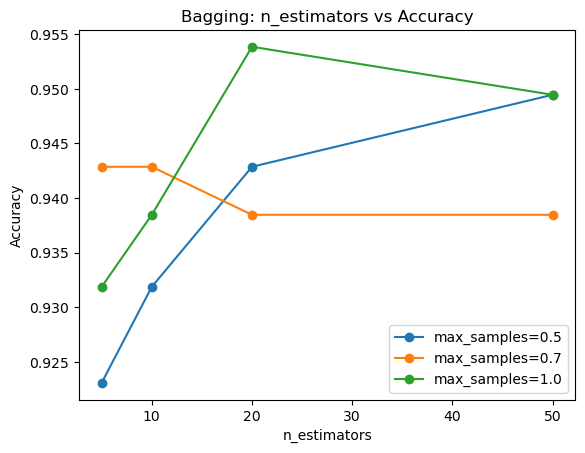

In [50]:
for m in bagging_results['max_samples'].unique():
    subset = bagging_results[bagging_results['max_samples'] == m]
    
    plt.plot(subset['n_estimators'], subset['Avg_CV_Accuracy'], marker='o', label=f'max_samples={m}')

plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Bagging: n_estimators vs Accuracy")
plt.legend()
plt.savefig("Bagging_n_estimators vs Accuracy")
plt.show()

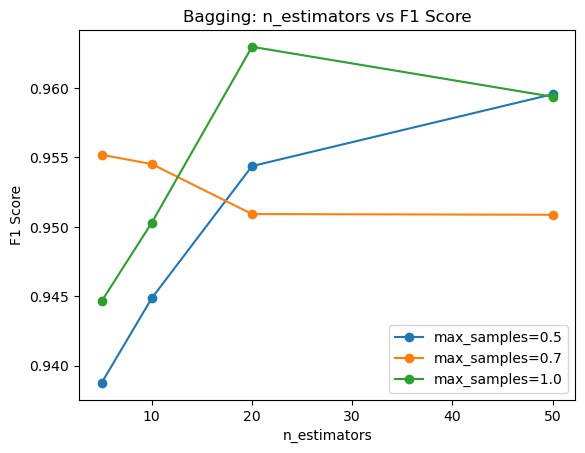

In [51]:
for m in bagging_results['max_samples'].unique():
    subset = bagging_results[bagging_results['max_samples'] == m]
    
    plt.plot(subset['n_estimators'], subset['Avg_CV_F1_Score'], marker='o', label=f'max_samples={m}')

plt.xlabel("n_estimators")
plt.ylabel("F1 Score")
plt.title("Bagging: n_estimators vs F1 Score")
plt.legend()
plt.savefig("Bagging_n_estimators vs F1 Score")
plt.show()

In [28]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada_model.fit(X_train_scaled, y_train)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_ada = ada_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada))
print("Recall:", recall_score(y_test, y_pred_ada))
print("F1 Score:", f1_score(y_test, y_pred_ada))

Accuracy: 0.9649122807017544
Precision: 0.9473684210526315
Recall: 1.0
F1 Score: 0.972972972972973


In [29]:
n_estimators_list = [10, 50, 100]
learning_rates = [0.01, 0.1, 1]

results_ada = []

for n in n_estimators_list:
    for lr in learning_rates:
        model = AdaBoostClassifier(
            n_estimators=n,
            learning_rate=lr,
            random_state=42
        )
        
        acc_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
        f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
        
        results_ada.append([
            n, lr,
            acc_scores.mean(),
            f1_scores.mean()
        ])

In [30]:
ada_results = pd.DataFrame(results_ada, columns=[
    'n_estimators',
    'learning_rate',
    'Avg_CV_Accuracy',
    'Avg_CV_F1_Score'
])

print(ada_results)

   n_estimators  learning_rate  Avg_CV_Accuracy  Avg_CV_F1_Score
0            10           0.01         0.912088         0.931346
1            10           0.10         0.927473         0.942994
2            10           1.00         0.942857         0.954533
3            50           0.01         0.931868         0.946115
4            50           0.10         0.958242         0.966955
5            50           1.00         0.964835         0.972015
6           100           0.01         0.934066         0.948002
7           100           0.10         0.962637         0.970402
8           100           1.00         0.967033         0.973728


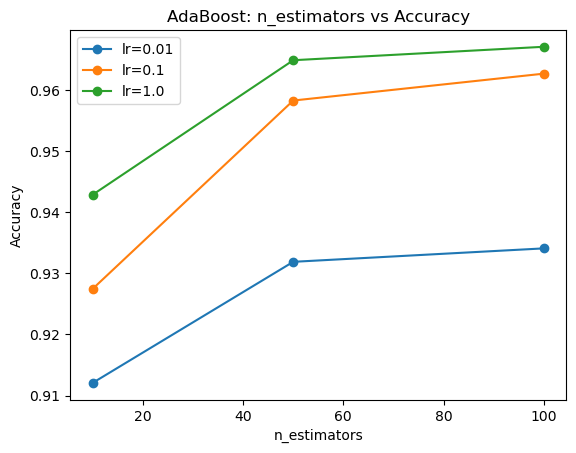

In [54]:
for lr in ada_results['learning_rate'].unique():
    subset = ada_results[ada_results['learning_rate'] == lr]
    
    plt.plot(subset['n_estimators'], subset['Avg_CV_Accuracy'], marker='o', label=f'lr={lr}')

plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("AdaBoost: n_estimators vs Accuracy")
plt.legend()
plt.savefig("AdaBoost_n_estimators vs Accuracy")
plt.show()

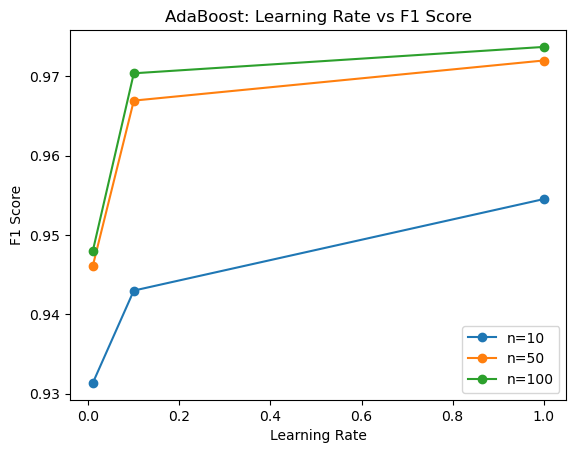

In [53]:
for n in ada_results['n_estimators'].unique():
    subset = ada_results[ada_results['n_estimators'] == n]
    
    plt.plot(subset['learning_rate'], subset['Avg_CV_F1_Score'], marker='o', label=f'n={n}')

plt.xlabel("Learning Rate")
plt.ylabel("F1 Score")
plt.title("AdaBoost: Learning Rate vs F1 Score")
plt.legend()
plt.savefig("AdaBoost_Learning Rate vs F1 Score")
plt.show()

In [32]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))

Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1 Score: 0.9659863945578231


In [33]:
# optional Gradient Boosting
n_estimators_list = [50, 100]
learning_rates = [0.01, 0.1]
max_depths = [3, 5]

results_gb = []

for n in n_estimators_list:
    for lr in learning_rates:
        for depth in max_depths:
            model = GradientBoostingClassifier(
                n_estimators=n,
                learning_rate=lr,
                max_depth=depth,
                random_state=42
            )
            
            acc_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
            f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
            
            results_gb.append([
                n, lr, depth,
                acc_scores.mean(),
                f1_scores.mean()
            ])

gb_results = pd.DataFrame(results_gb, columns=[
    'n_estimators',
    'learning_rate',
    'max_depth',
    'Avg_CV_Accuracy',
    'Avg_CV_F1_Score'
])

print(gb_results)

   n_estimators  learning_rate  max_depth  Avg_CV_Accuracy  Avg_CV_F1_Score
0            50           0.01          3         0.934066         0.948951
1            50           0.01          5         0.929670         0.944783
2            50           0.10          3         0.949451         0.959657
3            50           0.10          5         0.938462         0.951102
4           100           0.01          3         0.945055         0.956543
5           100           0.01          5         0.927473         0.942958
6           100           0.10          3         0.956044         0.965123
7           100           0.10          5         0.938462         0.951102


In [34]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

base_models = [
    ('svm', SVC(probability=True)),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier())
]


In [35]:
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5
)

stack_model.fit(X_train_scaled, y_train)

y_pred_stack = stack_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print("Precision:", precision_score(y_test, y_pred_stack))
print("Recall:", recall_score(y_test, y_pred_stack))
print("F1 Score:", f1_score(y_test, y_pred_stack))

Accuracy: 0.9736842105263158
Precision: 0.9726027397260274
Recall: 0.9861111111111112
F1 Score: 0.9793103448275862


In [36]:
acc_scores = cross_val_score(
    stack_model, X_train_scaled, y_train,
    cv=5, scoring='accuracy'
)

f1_scores = cross_val_score(
    stack_model, X_train_scaled, y_train,
    cv=5, scoring='f1'
)

print("Avg CV Accuracy:", acc_scores.mean())
print("Avg CV F1 Score:", f1_scores.mean())

Avg CV Accuracy: 0.9670329670329672
Avg CV F1 Score: 0.9702390617383122


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

bag_metrics = evaluate(y_test, y_pred_bag)
ada_metrics = evaluate(y_test, y_pred_ada)
gb_metrics = evaluate(y_test, y_pred_gb)
stack_metrics = evaluate(y_test, y_pred_stack)

In [38]:
comparison_df = pd.DataFrame([
    ['Bagging'] + bag_metrics,
    ['AdaBoost'] + ada_metrics,
    ['Gradient Boosting'] + gb_metrics,
    ['Stacking'] + stack_metrics
], columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

print(comparison_df)

               Model  Accuracy  Precision    Recall  F1 Score
0            Bagging  0.938596   0.957746  0.944444  0.951049
1           AdaBoost  0.964912   0.947368  1.000000  0.972973
2  Gradient Boosting  0.956140   0.946667  0.986111  0.965986
3           Stacking  0.973684   0.972603  0.986111  0.979310


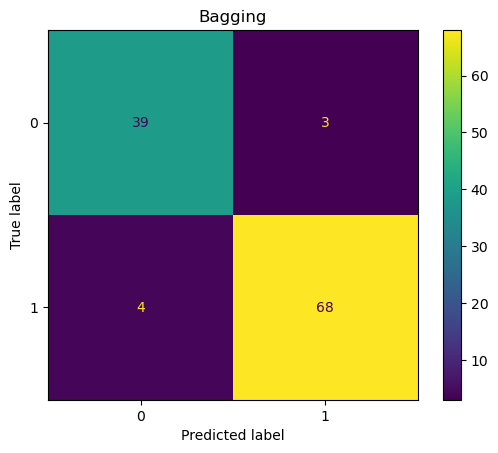

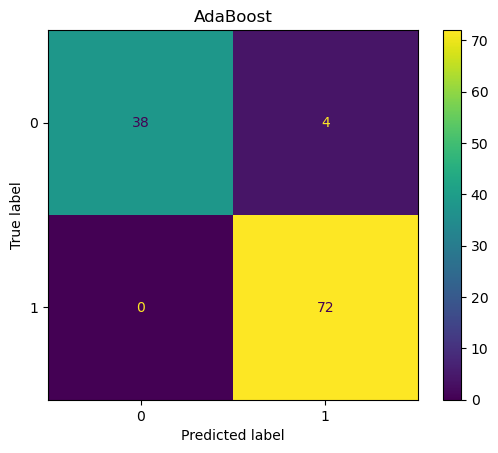

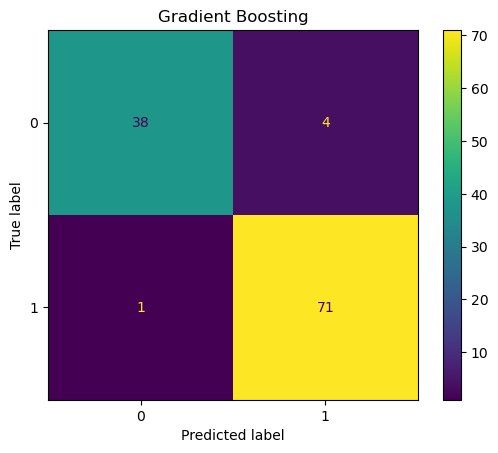

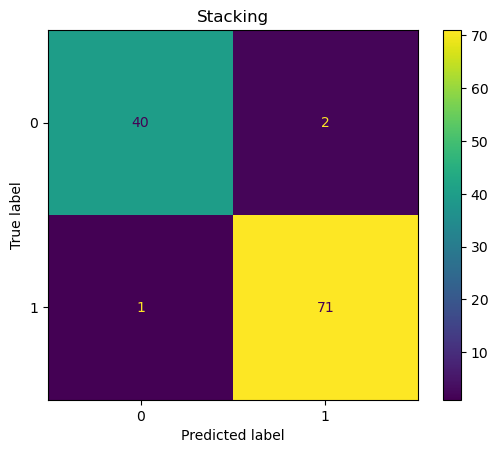

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Bagging": bagging_model,
    "AdaBoost": ada_model,
    "Gradient Boosting": gb_model,
    "Stacking": stack_model
}

for name, model in models.items():
    ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test)
    plt.title(name)
    plt.savefig(name)
    plt.show()

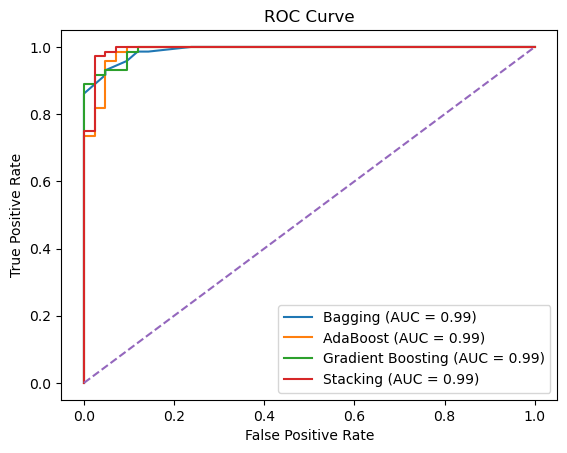

In [40]:
from sklearn.metrics import roc_curve, auc

plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("ROC_curve")
plt.show()

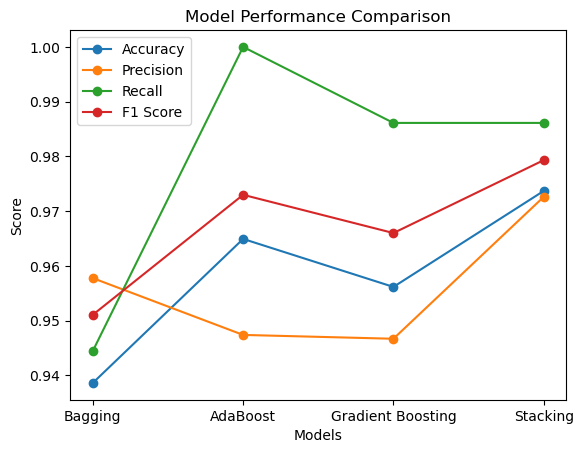

In [47]:
models = ['Bagging', 'AdaBoost', 'Gradient Boosting', 'Stacking']

accuracy = [0.938596, 0.964912, 0.956140, 0.973684]
precision = [0.957746, 0.947368, 0.946667, 0.972603]
recall = [0.944444, 1.000000, 0.986111, 0.986111]
f1 = [0.951049, 0.972973, 0.965986, 0.979310]

plt.figure()

plt.plot(models, accuracy, marker='o', label='Accuracy')
plt.plot(models, precision, marker='o', label='Precision')
plt.plot(models, recall, marker='o', label='Recall')
plt.plot(models, f1, marker='o', label='F1 Score')

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.savefig("Model Performance Comparison")
plt.show()